# Notebook 04 — Mô hình Random Forest

**Mục đích:** Xây dựng và đánh giá mô hình Random Forest Regression dự báo PM2.5.

**Quy trình:**
1. Tạo đặc trưng lag, rolling mean/std, đặc trưng thời gian.
2. Chia train (2022–2024) / test (2025) theo thứ tự thời gian.
3. Huấn luyện và tối ưu siêu tham số.
4. Dự báo trên tập kiểm thử.
5. Phân tích mức độ quan trọng của đặc trưng.
6. Đánh giá MAE, RMSE, R².

**Đầu vào:** `data/processed/clean_data.csv`  
**Đầu ra:** `results/rf_predictions.csv`


In [1]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

from src.data_processor import load_clean
from src.rf_model import prepare_rf_data, split_rf_data, train_rf, forecast_rf, get_feature_importance
from src.evaluator import compute_metrics, naive_forecast
from src.visualizer import plot_forecast_vs_actual, plot_feature_importance
from src.config import TARGET_COL

df = load_clean()
print(f'Dữ liệu: {len(df)} ngày')

Dữ liệu: 1265 ngày


## 1. Chuẩn bị đặc trưng

In [2]:
feat_df, y, feature_cols = prepare_rf_data(df)

print(f'Số đặc trưng:  {len(feature_cols)}')
print(f'Danh sách:     {feature_cols}')
display(feat_df.head())

2026-08-05 20:48:49,431 [INFO] Ma trận đặc trưng: 1251 mẫu × 14 đặc trưng (2022-01-27 → 2025-06-30)


Số đặc trưng:  14
Danh sách:     ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'day_of_week', 'month', 'quarter', 'season', 'year']


,PM2.5,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_std_7,day_of_week,month,quarter,season,year
date,,,,,,,,,,,,,,,
2022-01-27,51.930833,55.805417,53.263750,101.527917,99.541667,75.319583,70.199028,79.744048,78.294643,20.977631,3,1,1,4,2022
2022-01-28,59.458333,51.930833,55.805417,53.263750,77.847500,96.333333,53.666667,72.942500,76.624018,21.206005,4,1,1,4,2022
2022-01-29,49.166667,59.458333,51.930833,55.805417,70.305417,106.416667,55.731528,70.315476,73.990089,21.631855,5,1,1,4,2022
2022-01-30,31.263750,49.166667,59.458333,51.930833,99.916667,63.527917,53.518611,67.295655,69.900804,23.061727,6,1,1,4,2022
2022-01-31,40.041667,31.263750,49.166667,59.458333,101.527917,41.610833,46.629583,57.488095,67.596220,21.416154,0,1,1,4,2022


## 2. Chia tập dữ liệu (theo thứ tự thời gian)

In [3]:
X_train, X_test, y_train, y_test = split_rf_data(feat_df, y, feature_cols)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

2026-08-05 20:48:49,479 [INFO] Tập huấn luyện RF: 1,070 mẫu | Tập kiểm thử RF: 181 mẫu


X_train: (1070, 14) | X_test: (181, 14)


## 3. Huấn luyện mô hình Random Forest (tham số mặc định từ config)

In [4]:
rf_model = train_rf(X_train, y_train)
print('✅ Huấn luyện hoàn tất!')

2026-08-05 20:48:49,499 [INFO] Huấn luyện Random Forest với tham số: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
2026-08-05 20:48:49,668 [INFO] Huấn luyện Random Forest hoàn tất.


✅ Huấn luyện hoàn tất!


## 4. (Tuỳ chọn) Tìm kiếm siêu tham số bằng RandomizedSearchCV
*Bỏ qua cell này nếu không muốn tối ưu thêm.*

In [5]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 4],
}

# Chú ý: Với dữ liệu chuỗi thời gian, KHÔNG dùng cv ngẫu nhiên.
# Dùng TimeSeriesSplit để đảm bảo thứ tự thời gian.
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)
print(f'Tham số tốt nhất: {search.best_params_}')

# Cập nhật mô hình nếu kết quả tốt hơn
rf_model = search.best_estimator_

Tham số tốt nhất: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 5}


## 5. Dự báo trên tập kiểm thử (2025)

In [6]:
rf_preds = forecast_rf(rf_model, X_test, y_test)
print(f'Số ngày dự báo: {len(rf_preds)}')
print(rf_preds.head())

2026-08-05 20:48:54,407 [INFO] Kết quả dự báo RF lưu tại: D:\DuAn\QuanLyBuiMinPM25\results\rf_predictions.csv


Số ngày dự báo: 181
date
2025-01-01     80.651099
2025-01-02     99.428031
2025-01-03    106.171241
2025-01-04     95.575074
2025-01-05     96.116797
Name: rf_pred, dtype: float64


## 6. Biểu đồ dự báo vs. thực tế

2026-08-05 20:48:54,589 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\08_rf_forecast.png


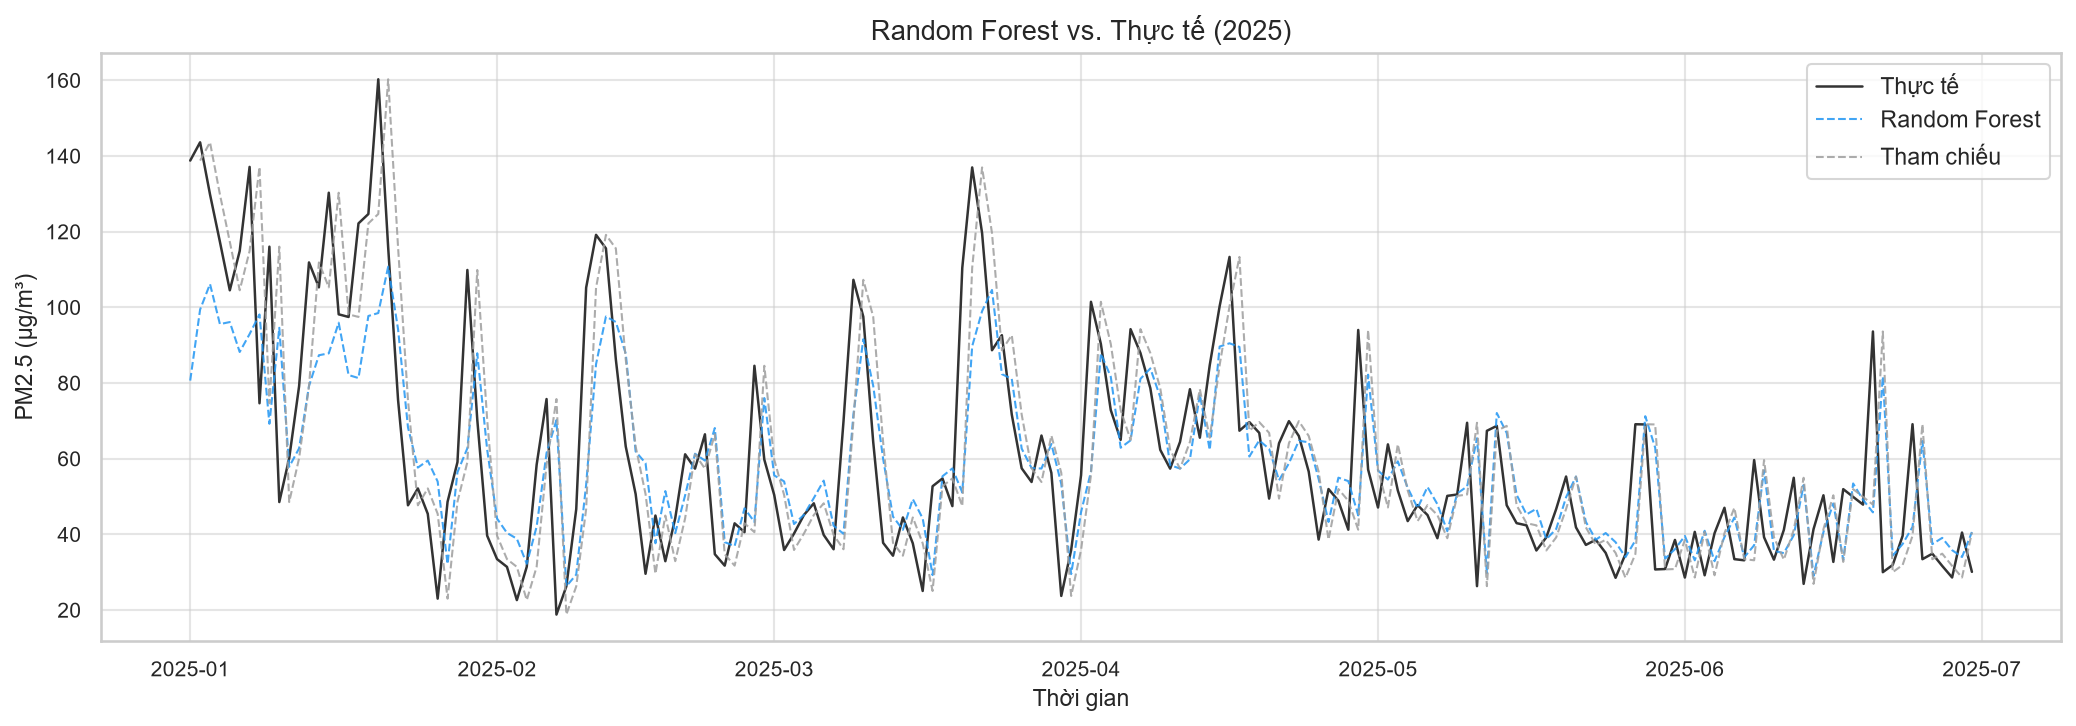

In [7]:
naive_preds = naive_forecast(y_test)

fig = plot_forecast_vs_actual(
    actual=y_test,
    preds={'Random Forest': rf_preds, 'Tham chiếu': naive_preds},
    title='Random Forest vs. Thực tế (2025)',
    filename='08_rf_forecast'
)
plt.show()

## 7. Mức độ quan trọng của đặc trưng

2026-08-05 20:48:54,746 [INFO] Top 10 đặc trưng quan trọng nhất:
2026-08-05 20:48:54,747 [INFO] lag_1              0.859097
lag_14             0.030196
lag_2              0.016142
rolling_mean_3     0.015298
lag_7              0.014268
rolling_mean_14    0.014154
rolling_std_7      0.012126
rolling_mean_7     0.009754
month              0.007486
lag_3              0.006876
2026-08-05 20:48:54,872 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\09_feature_importance.png


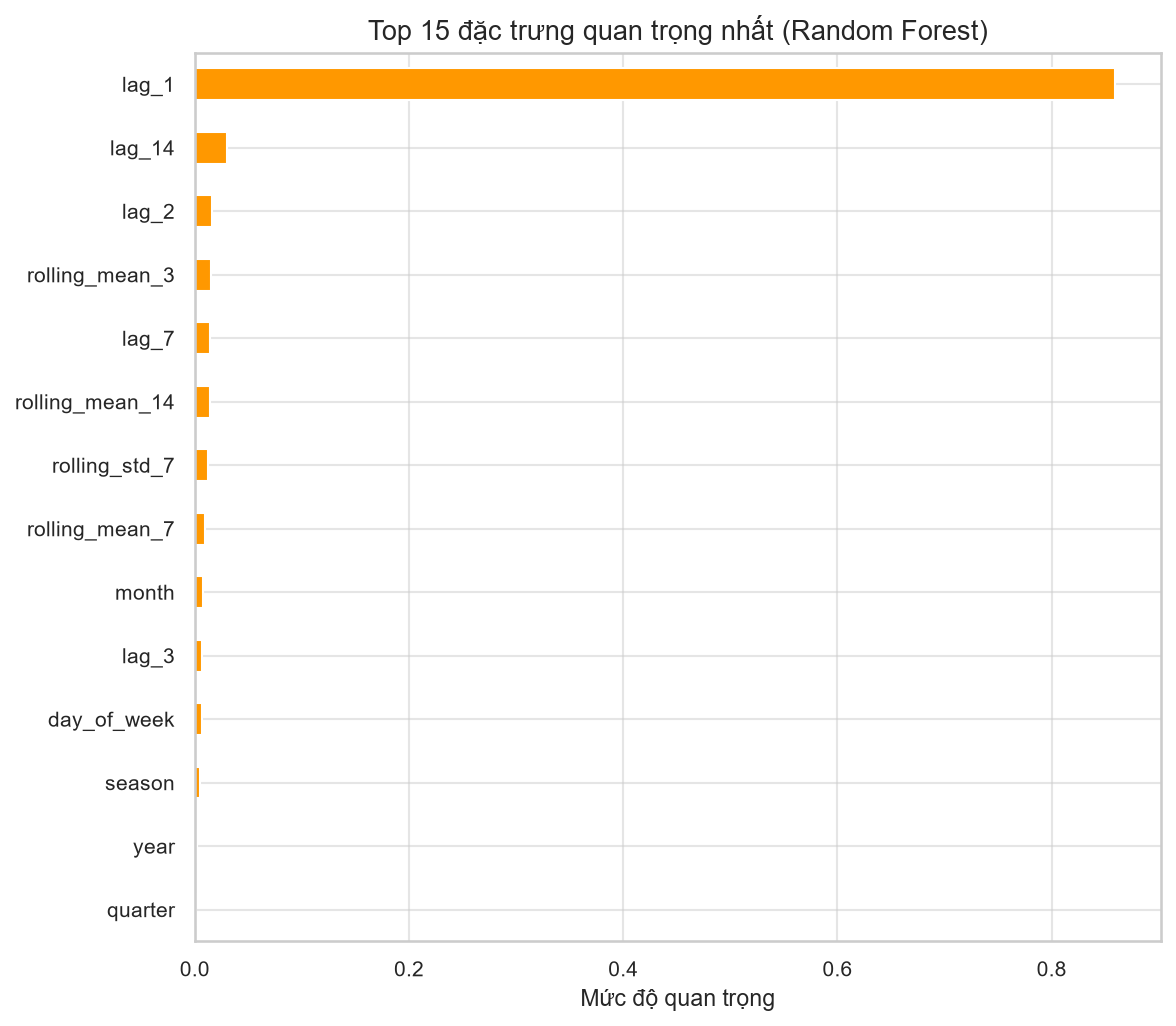


Top 10 đặc trưng:


,Mức độ quan trọng
lag_1,0.8591
lag_14,0.0302
lag_2,0.0161
rolling_mean_3,0.0153
lag_7,0.0143
rolling_mean_14,0.0142
rolling_std_7,0.0121
rolling_mean_7,0.0098
month,0.0075
lag_3,0.0069


In [8]:
importances = get_feature_importance(rf_model, feature_cols)
fig = plot_feature_importance(importances, top_n=15)
plt.show()

print('\nTop 10 đặc trưng:')
display(importances.head(10).to_frame('Mức độ quan trọng').round(4))

## 8. Đánh giá mô hình Random Forest

In [9]:
metrics_rf    = compute_metrics(y_test, rf_preds,    model_name='Random Forest')
metrics_naive = compute_metrics(y_test, naive_preds, model_name='Dự báo tham chiếu')

result_df = pd.DataFrame([metrics_naive, metrics_rf]).set_index('Mô hình')
display(result_df)

improvement = (metrics_naive['RMSE'] - metrics_rf['RMSE']) / metrics_naive['RMSE'] * 100
print(f'\nRandom Forest cải thiện RMSE so với Tham chiếu: {improvement:.2f}%')

2026-08-05 20:48:54,991 [INFO] [Random Forest] MAE=15.8635 | RMSE=21.2432 | R²=0.4951
2026-08-05 20:48:54,994 [INFO] [Dự báo tham chiếu] MAE=16.8090 | RMSE=22.3952 | R²=0.4203


,MAE,RMSE,R²
Mô hình,,,
Dự báo tham chiếu,16.8090,22.3952,0.4203
Random Forest,15.8635,21.2432,0.4951



Random Forest cải thiện RMSE so với Tham chiếu: 5.14%


---
✅ **Hoàn thành!** Chạy tiếp `05_model_comparison.ipynb`.